# How Popular Music Has Changed Over Time
### Billboard Hot 100 × MusicBrainz — 1958–2024

**Data sources**
| Source | What we get |
|---|---|
| Billboard Hot 100 CSV (Kaggle) | Chart rank, weeks on chart, peak position, 1958–2024 |
| MusicBrainz REST API | Track duration, release year, genre tags, artist country, label |

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis import (
    load_merged,
    summary_by_decade,
    plot_duration_over_time,
    plot_genre_shifts,
    plot_country_origins,
    plot_country_over_time,
    plot_weeks_on_chart_over_time,
)

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


## 1. Load the merged dataset

In [2]:
df = load_merged()   # loads data/processed/merged_dataset.csv
print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f'Date range: {df["chart_date"].min().date()} → {df["chart_date"].max().date()}')
print(f'Unique songs: {df[["title","artist"]].drop_duplicates().shape[0]:,}')
df.head()

Rows: 343,600  |  Columns: 17
Date range: 1958-08-04 → 2024-06-08
Unique songs: 31,344


,chart_date,year,decade,rank,title,artist,peak_position,weeks_on_chart,duration_sec,duration_min,mb_duration_ms,primary_genre,mb_genre_tags,mb_artist_country,mb_label,mb_release_year,last_week
0,1990-06-16,1990,1990s,54,"""B"" Girls",Young And Restless,54,7,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,55.0
1,1990-06-09,1990,1990s,55,"""B"" Girls",Young And Restless,55,6,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,58.0
2,1990-06-23,1990,1990s,57,"""B"" Girls",Young And Restless,54,8,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,54.0
3,1990-06-02,1990,1990s,58,"""B"" Girls",Young And Restless,58,5,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,60.0
4,1990-05-26,1990,1990s,60,"""B"" Girls",Young And Restless,60,4,240.0,4.0,240000.0,NaN,NaN,US,NaN,1990.0,68.0


In [3]:
# Data coverage
coverage = pd.DataFrame({
    'Column': df.columns,
    'Non-null %': (df.notna().mean() * 100).round(1).values
}).sort_values('Non-null %', ascending=False)
display(coverage)

,Column,Non-null %
0,chart_date,100.0
1,year,100.0
2,decade,100.0
3,rank,100.0
4,title,100.0
5,artist,100.0
6,peak_position,100.0
7,weeks_on_chart,100.0
16,last_week,90.6
13,mb_artist_country,79.4


## 2. Summary by Decade

In [4]:
summary = summary_by_decade(df)
display(summary)

,Duration Sec,Weeks On Chart,Title
decade,,,
1950s,146.10,5.0,7400
1960s,158.00,5.0,52100
1970s,211.15,6.0,52200
1980s,246.10,7.0,52200
1990s,251.20,9.0,52100
2000s,232.00,10.0,52200
2010s,214.90,10.0,52200
2020s,191.00,9.0,23200


## 3. Song Duration Over Time
The 3-minute radio edit became an industry standard — but did streaming change it?

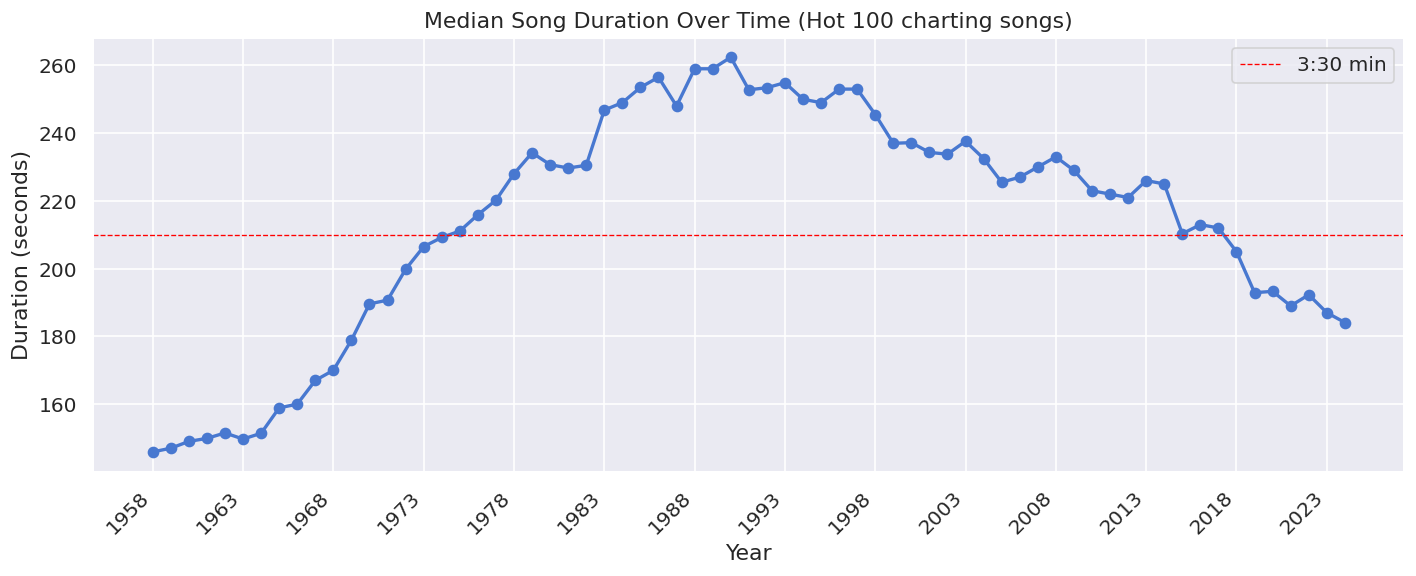

In [5]:
fig = plot_duration_over_time(df, by='year')
plt.show()

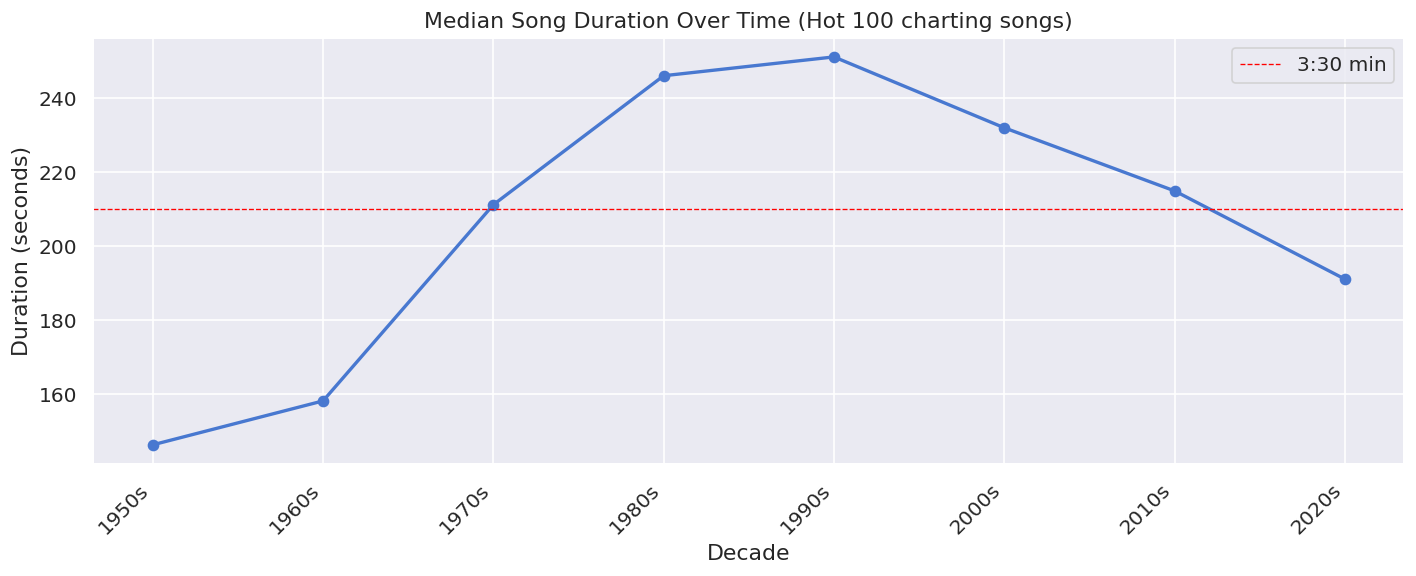

In [6]:
fig = plot_duration_over_time(df, by='decade')
plt.show()

## 4. Genre Shifts by Decade
Rock → Pop → Hip-Hop — let's see it in the data.

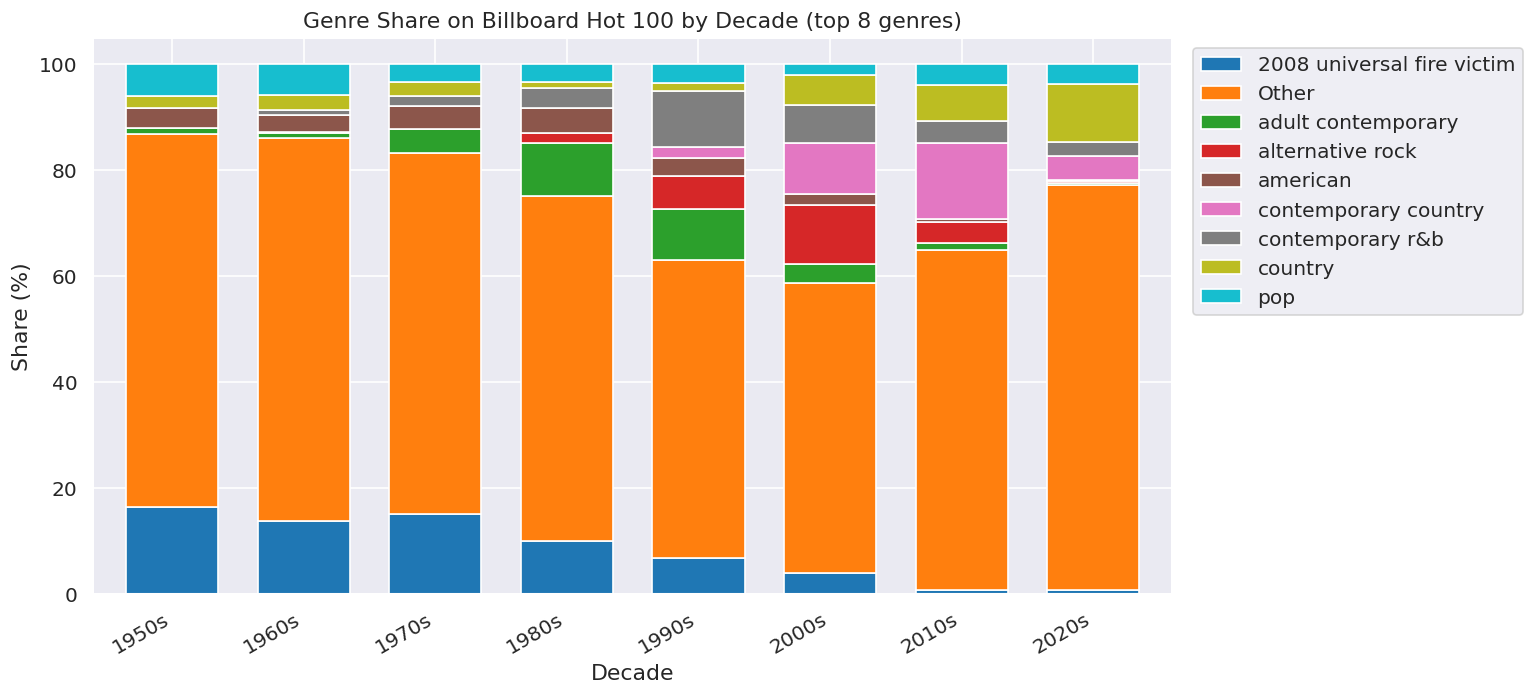

In [7]:
fig = plot_genre_shifts(df, top_n=8)
plt.show()

## 5. Where Do Artists Come From?
Has the Hot 100 become more or less American over time?

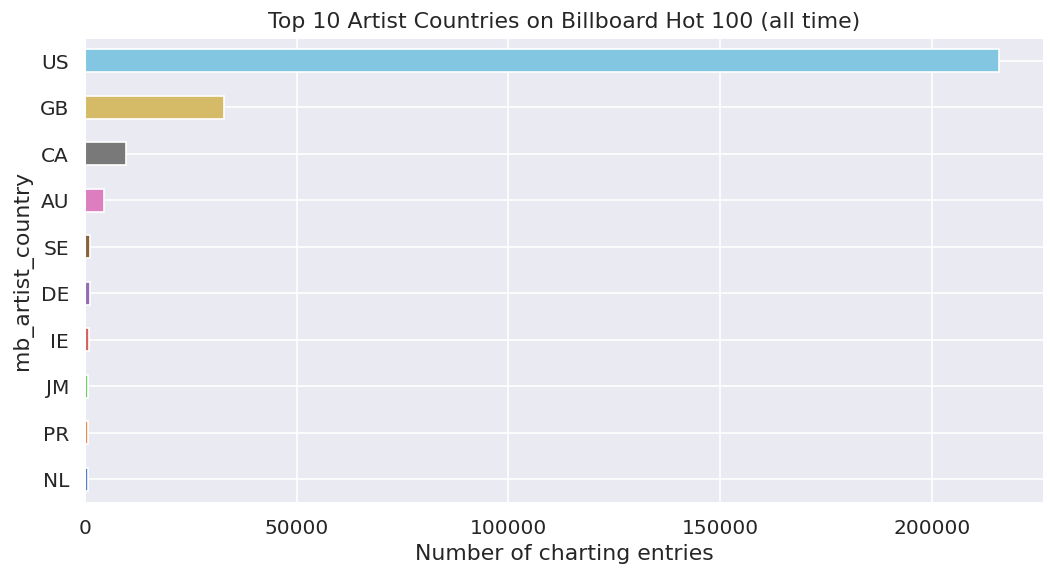

In [8]:
fig = plot_country_origins(df, top_n=10)
plt.show()

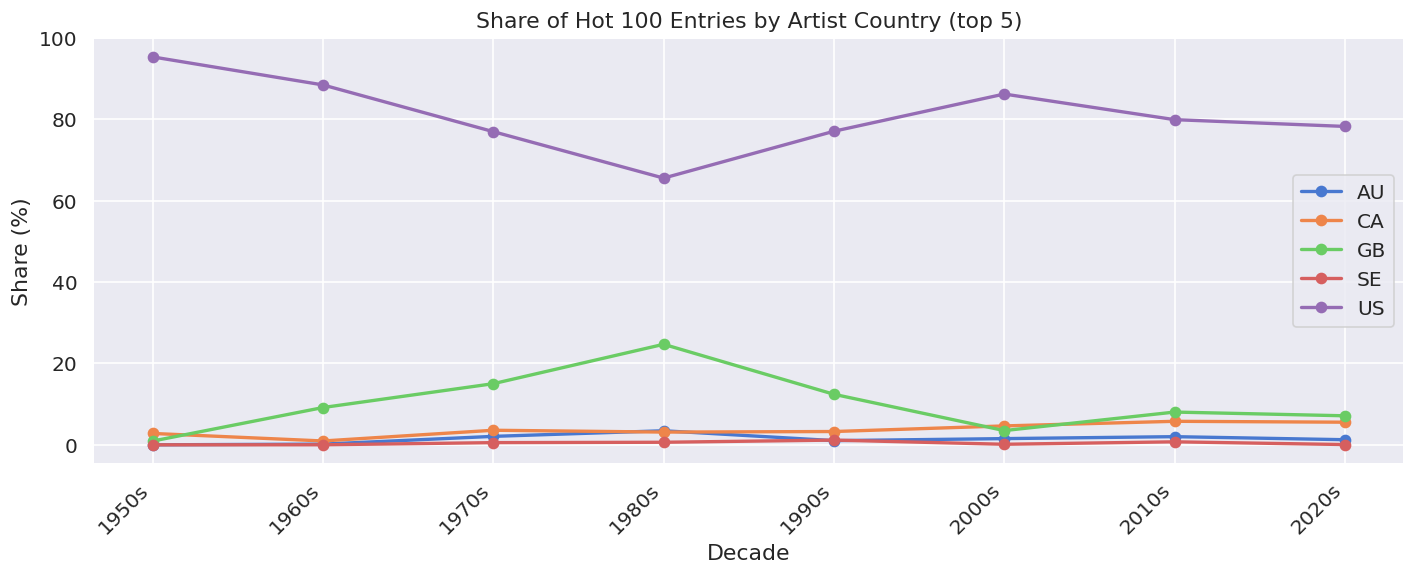

In [9]:
fig = plot_country_over_time(df, top_countries=5)
plt.show()

## 6. Chart Longevity — Are Hits Sticking Around Longer?
Streaming has changed how songs accumulate chart weeks.

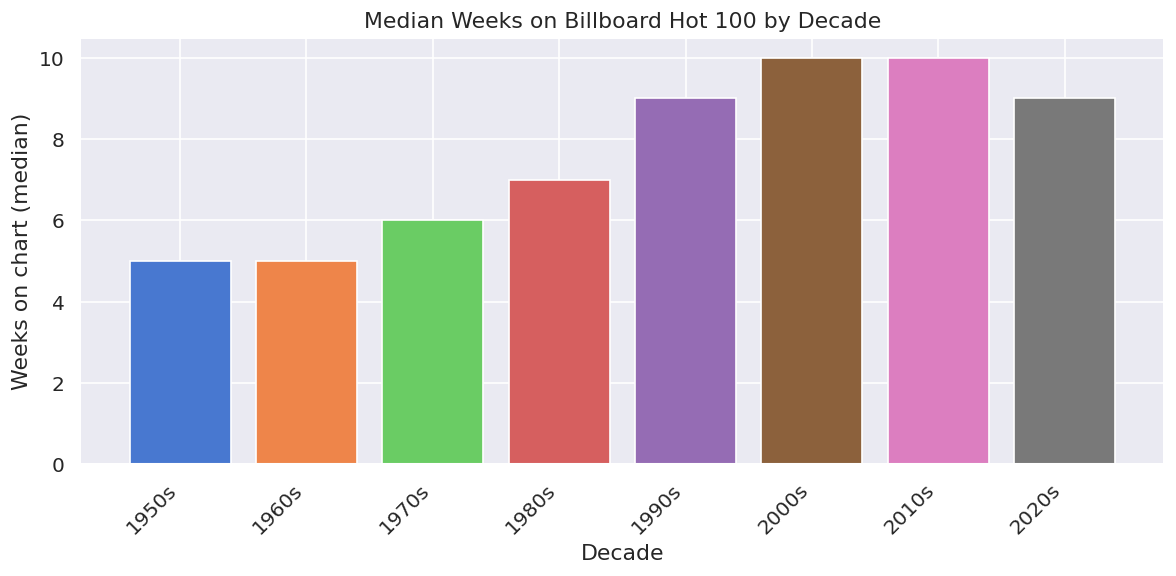

In [10]:
fig = plot_weeks_on_chart_over_time(df)
plt.show()

## 8. Deep Dive — Your Custom Analysis
Use these cells to explore specific questions.

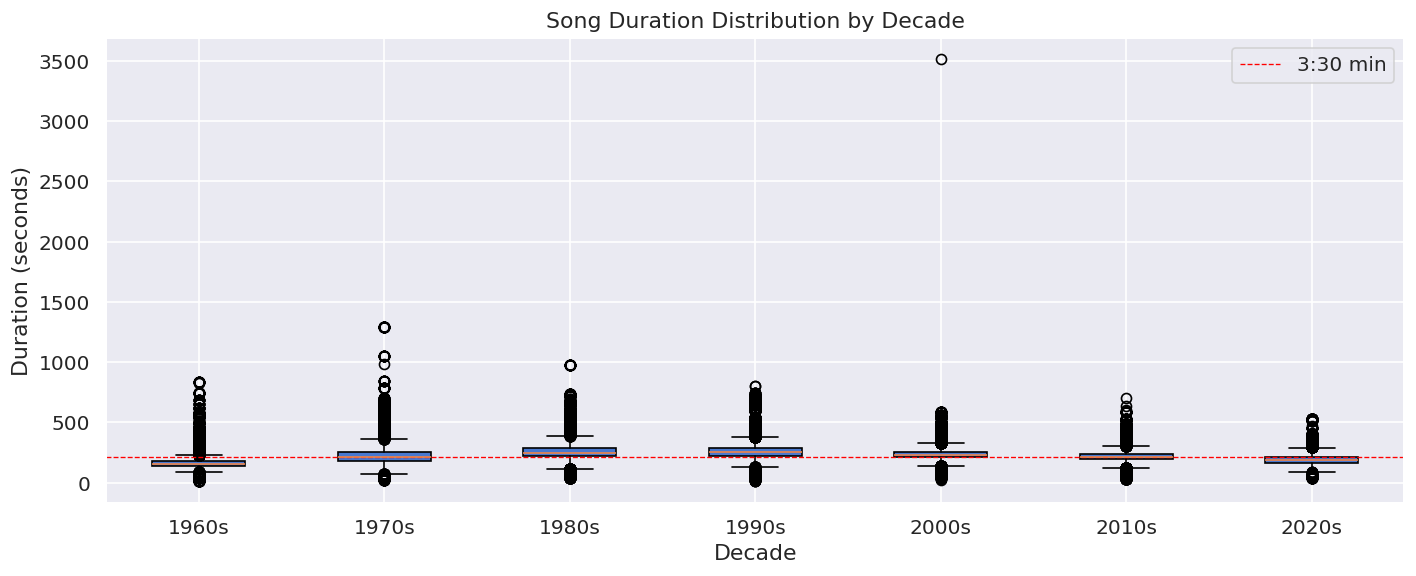

In [11]:
# Example: duration distribution by decade (box plot)
sub = df.dropna(subset=['duration_sec', 'decade'])
decades = [d for d in ['1960s','1970s','1980s','1990s','2000s','2010s','2020s']
           if d in sub['decade'].unique()]

fig, ax = plt.subplots(figsize=(12, 5))
data_per_decade = [sub[sub['decade'] == d]['duration_sec'].dropna() for d in decades]
ax.boxplot(data_per_decade, labels=decades, patch_artist=True)
ax.set_title('Song Duration Distribution by Decade')
ax.set_ylabel('Duration (seconds)')
ax.set_xlabel('Decade')
ax.axhline(210, color='red', linestyle='--', linewidth=0.8, label='3:30 min')
ax.legend()
plt.tight_layout()
plt.show()